# Markerless Motion Capture Validation — MediaPipe Results

## Imports & setup

In [4]:
import glob, os
import numpy as np
import pandas as pd
from utilities import utils
from tasks import cmj, dj, velocity, rjt, hip, nordic, slr, sls
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

def load_task(folder, drop_ul=False, only_ul=False):
    files = sorted(p for p in glob.glob(f"data/keypoints/{folder}/*.txt")
                   if "world" not in p.lower())
    if drop_ul: files = [p for p in files if "UL" not in p.upper()]
    if only_ul: files = [p for p in files if "UL" in p.upper()]
    return files

result_dataframes = []

## 1 · Jump Height

In [ ]:

_cmj_all = load_task("cmj")
cmj_bl_files = sorted(p for p in _cmj_all if "UL" not in os.path.basename(p).upper())
cmj_ul_files = sorted(p for p in _cmj_all if "UL" in os.path.basename(p).upper())
print(len(cmj_bl_files), "bilateral,", len(cmj_ul_files), "unilateral")

16 bilateral, 16 unilateral


In [ ]:
cmj_data = utils.read_list('cmj_data')
dj_data  = utils.read_list('dj_data')

_cmj_all = load_task("cmj")
cmj_bl_files = sorted(p for p in _cmj_all if "UL" not in os.path.basename(p).upper())
cmj_ul_files = sorted(p for p in _cmj_all if "UL" in os.path.basename(p).upper())
print(len(cmj_bl_files), "bilateral,", len(cmj_ul_files), "unilateral")

16 bilateral, 16 unilateral


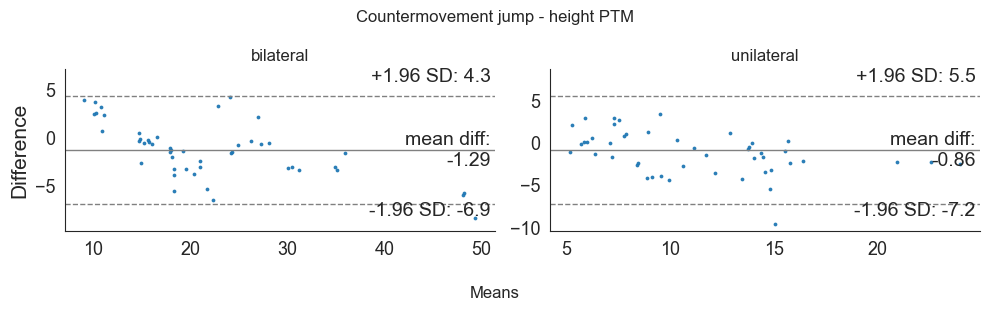

,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Jump height,CMJ bilateral,height,Force plates,2.52,0.98,0.95
1,Jump height,CMJ unilateral,height,Force plates,2.36,0.88,0.76
2,Jump height,CMJ bilateral,gravity,Force plates,6.21,0.97,0.77
3,Jump height,CMJ unilateral,gravity,Force plates,5.05,0.84,0.53


In [ ]:
all_jumps_h = cmj.assemble_jumps(cmj_bl_files, cmj_ul_files, cmj_data,
                                 ptm='height', trim_first_ul={'P17','P11'})
all_jumps_g = cmj.assemble_jumps(cmj_bl_files, cmj_ul_files, cmj_data,
                                 ptm='gravity', trim_first_ul={'P17','P11'})
cmj.ba_plots(all_jumps_h, title='height PTM')
cmj_h = cmj.get_metrics(all_jumps_h, ptm='height')
cmj_g = cmj.get_metrics(all_jumps_g, ptm='gravity')
pd.concat([cmj_h, cmj_g], ignore_index=True)

In [ ]:
dj_bl = load_task("dj", drop_ul=True)
dj_ul = load_task("dj", only_ul=True)
dj_jh, dj_ft, dj_ct = dj.get_metrics(dj_bl, dj_ul, dj_data, ptm='height')
dj_jh

,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Jump height,Drop jump bilateral,height,Force plates,3.00,0.83,0.80
1,Jump height,Drop jump unilateral,height,Force plates,2.29,0.67,0.62


In [9]:
result_dataframes.extend([cmj_h, cmj_g, dj_jh])

## 2 · Velocity-Based Tests

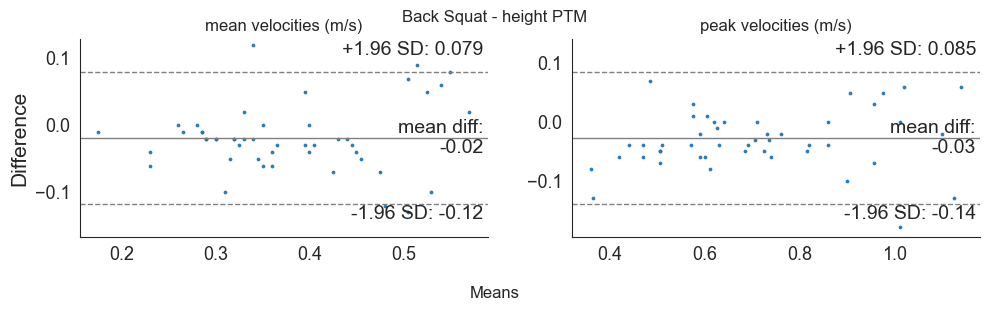

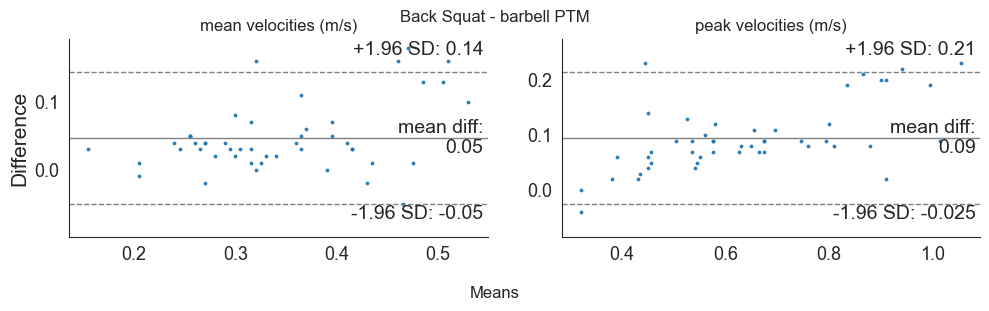

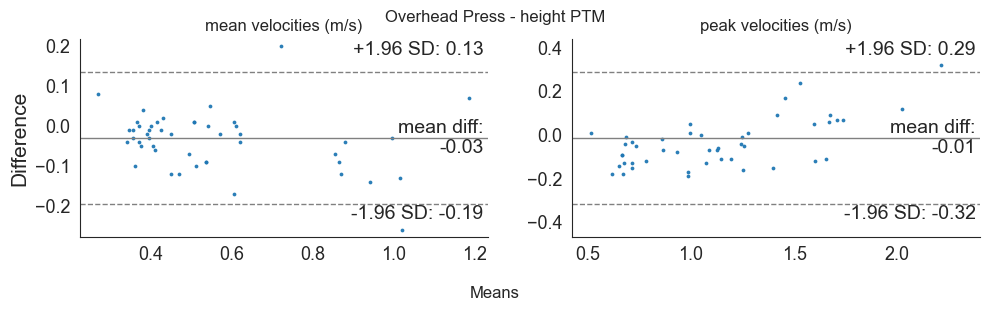

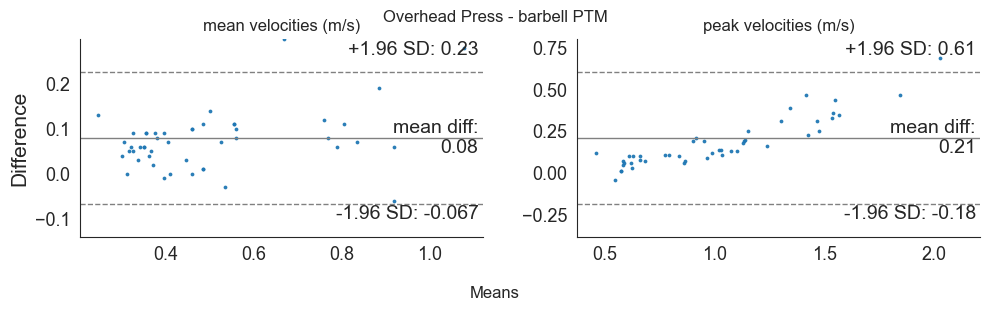

,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Peak velocity,Back Squat,height,Optical motion capture,0.05,0.85,0.95
1,Mean velocity,Back Squat,height,Optical motion capture,0.04,0.83,0.86
2,Peak velocity,Back Squat,barbell,Optical motion capture,0.10,0.85,0.85
3,Mean velocity,Back Squat,barbell,Optical motion capture,0.05,0.85,0.76
4,Peak velocity,Overhead Press,height,Optical motion capture,0.11,0.89,0.94
5,Mean velocity,Overhead Press,height,Optical motion capture,0.06,0.80,0.92
6,Peak velocity,Overhead Press,barbell,Optical motion capture,0.21,0.90,0.80
7,Mean velocity,Overhead Press,barbell,Optical motion capture,0.08,0.82,0.87


In [10]:
bsq = load_task("bsq"); ohp = load_task("ohp")
bsq_data = utils.read_list('bsq_data'); ohp_data = utils.read_list('ohp_data')

bsq_h = velocity.get_metrics(bsq, bsq_data, task='bsq', task_label='Back Squat', ptm='height')
bsq_b = velocity.get_metrics(bsq, bsq_data, task='bsq', task_label='Back Squat', ptm='barbell')
ohp_h = velocity.get_metrics(ohp, ohp_data, task='ohp', task_label='Overhead Press', ptm='height')
ohp_b = velocity.get_metrics(ohp, ohp_data, task='ohp', task_label='Overhead Press', ptm='barbell')

result_dataframes.extend([bsq_h, bsq_b, ohp_h, ohp_b])
pd.concat([bsq_h, bsq_b, ohp_h, ohp_b], ignore_index=True)

## 3 · Temporal Metrics

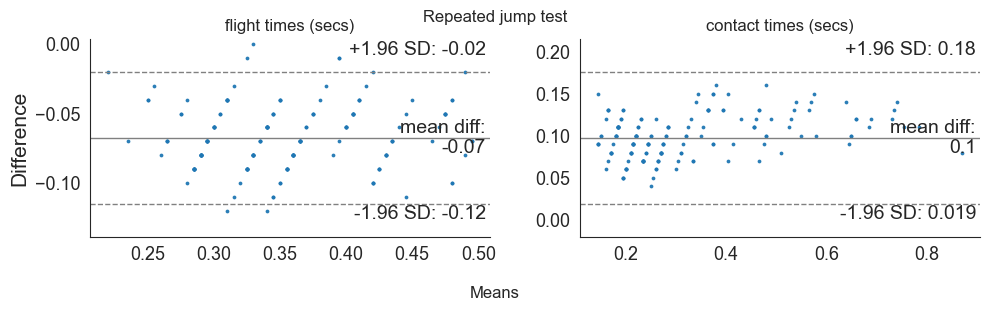

,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Flight time,Drop jump bilateral,height,Force plates,0.05,0.32,0.34
1,Flight time,Drop jump unilateral,height,Force plates,0.07,0.18,0.21
2,Contact time,Drop jump bilateral,height,Force plates,0.04,0.47,0.81
3,Contact time,Drop jump unilateral,height,Force plates,0.06,0.58,0.66
4,Flight time,Repeated jump test,height,Force plates,0.07,0.68,0.60
5,Contact time,Repeated jump test,height,Force plates,0.10,0.91,0.82


In [ ]:
rjt_files = load_task("rjt")
rjt_data  = utils.read_list('rjt_data')
rjt_m = rjt.get_metrics(rjt_files, rjt_data, ptm='height')

result_dataframes.extend([dj_ft, dj_ct, rjt_m])
pd.concat([dj_ft, dj_ct, rjt_m], ignore_index=True)

## 4 · Angular Metrics


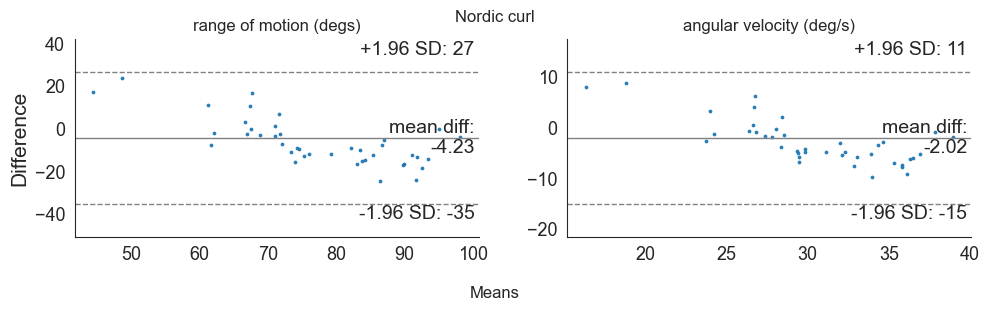

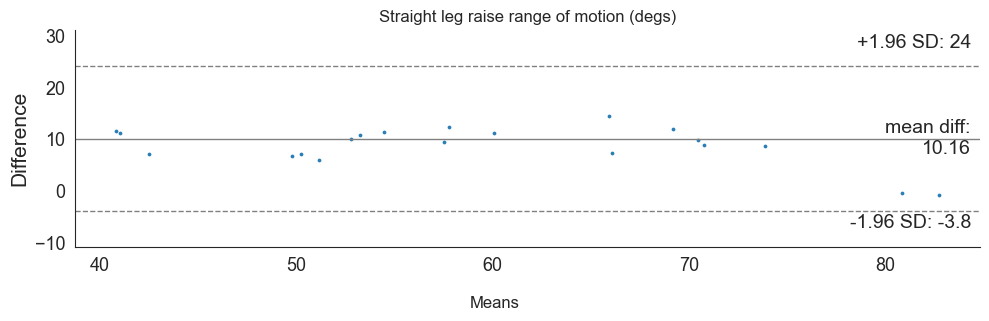

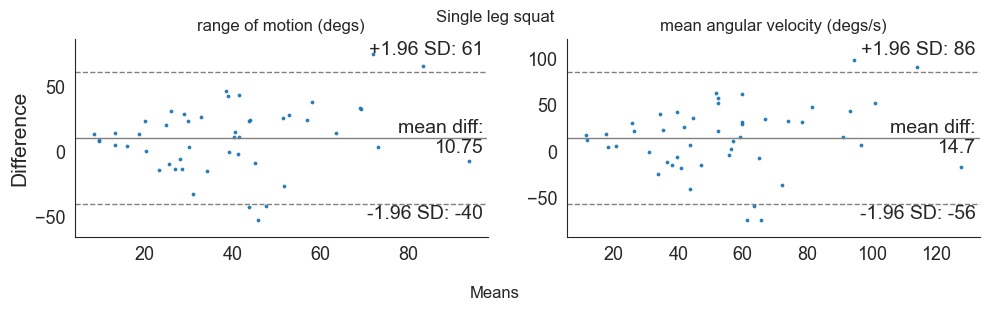

[hip] P06 her: 3/2 reps, skipped


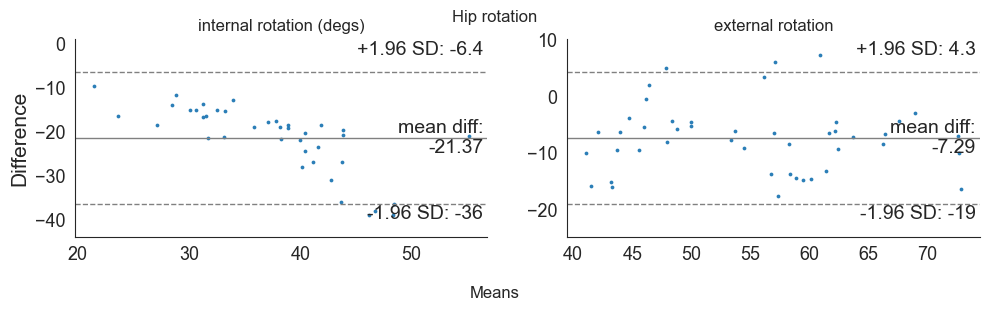

,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Range of motion,Nordic curl,N/A,Optical motion capture,11.93,0.60,0.41
1,Angular velocity,Nordic curl,N/A,Optical motion capture,5.04,0.58,0.39
2,Range of motion,Straight leg raise,N/A,Optical motion capture,10.26,0.78,0.64
3,Range of motion,Single leg squat,N/A,Optical motion capture,22.41,0.54,0.36
4,Angular velocity,Single leg squat,N/A,Optical motion capture,31.23,0.53,0.32
5,Range of motion,Hip internal rotation,N/A,Optical motion capture,21.37,0.87,0.13
6,Range of motion,Hip external rotation,N/A,Optical motion capture,8.36,0.94,0.63


In [12]:
nordic_data = utils.read_list('nordic_data')
slr_data    = utils.read_list('slr_data')
sls_data    = utils.read_list('sls_data')
hip_data    = utils.read_list('hip_data')

nordic_m = nordic.get_metrics(load_task("nordic"), nordic_data)
slr_m    = slr.get_metrics(load_task("slr"), slr_data)
sls_m    = sls.get_metrics(load_task("slsq"), sls_data)
hip_m    = hip.get_metrics("data/keypoints/hip", hip_data)

result_dataframes.extend([nordic_m, slr_m, sls_m, hip_m])
pd.concat([nordic_m, slr_m, sls_m, hip_m], ignore_index=True)

## 5 · Combined Results Table

In [13]:
final = pd.concat(result_dataframes, ignore_index=True)
cols = ['Metric','Task','PTM Ref','Ground Truth','MAE','Reliability','ICC']
final = final[[c for c in cols if c in final.columns]]
final

,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Jump height,CMJ bilateral,height,Force plates,2.52,0.98,0.95
1,Jump height,CMJ unilateral,height,Force plates,2.36,0.88,0.76
2,Jump height,CMJ bilateral,gravity,Force plates,6.21,0.97,0.77
3,Jump height,CMJ unilateral,gravity,Force plates,5.05,0.84,0.53
4,Jump height,Drop jump bilateral,height,Force plates,3.00,0.83,0.80
5,Jump height,Drop jump unilateral,height,Force plates,2.29,0.67,0.62
6,Peak velocity,Back Squat,height,Optical motion capture,0.05,0.85,0.95
7,Mean velocity,Back Squat,height,Optical motion capture,0.04,0.83,0.86
8,Peak velocity,Back Squat,barbell,Optical motion capture,0.10,0.85,0.85
9,Mean velocity,Back Squat,barbell,Optical motion capture,0.05,0.85,0.76


In [14]:
os.makedirs("results", exist_ok=True)
final.to_csv("results/mediapipe_results.csv", index=False)
print("saved results/mediapipe_results.csv —", len(final), "rows")

saved results/mediapipe_results.csv — 27 rows


In [15]:
# --- format the results table to match the OpenPose layout ---
fmt = final.copy()

metric_order = ['Angular velocity', 'Contact time', 'Flight time',
                'Jump height', 'Mean velocity', 'Peak velocity', 'Range of motion']
fmt['Metric'] = pd.Categorical(fmt['Metric'], categories=metric_order, ordered=True)

fmt = (fmt
       .sort_values(['Metric', 'Task', 'PTM Ref'])
       .set_index(['Metric', 'Task']))

col_order = ['PTM Ref', 'Ground Truth', 'MAE', 'Reliability', 'ICC']
fmt = fmt[[c for c in col_order if c in fmt.columns]]

fmt   # display the grouped multi-index frame directly

PTM Ref            Ground Truth  \
Metric           Task                                                     
Angular velocity Nordic curl                N/A  Optical motion capture   
                 Single leg squat           N/A  Optical motion capture   
Contact time     Drop jump bilateral     height            Force plates   
                 Drop jump unilateral    height            Force plates   
                 Repeated jump test      height            Force plates   
Flight time      Drop jump bilateral     height            Force plates   
                 Drop jump unilateral    height            Force plates   
                 Repeated jump test      height            Force plates   
Jump height      CMJ bilateral          gravity            Force plates   
                 CMJ bilateral           height            Force plates   
                 CMJ unilateral         gravity            Force plates   
                 CMJ unilateral          height            Force plates   
                 Drop jump bilateral     height            Force plates   
                 Drop jump unilateral    height            Force plates   
Mean velocity    Back Squat             barbell  Optical motion capture   
                 Back Squat              height  Optical motion capture   
                 Overhead Press         barbell  Optical motion capture   
                 Overhead Press          height  Optical motion capture   
Peak velocity    Back Squat             barbell  Optical motion capture   
                 Back Squat              height  Optical motion capture   
                 Overhead Press         barbell  Optical motion capture   
                 Overhead Press          height  Optical motion capture   
Range of motion  Hip external rotation      N/A  Optical motion capture   
                 Hip internal rotation      N/A  Optical motion capture   
                 Nordic curl                N/A  Optical motion capture   
                 Single leg squat           N/A  Optical motion capture   
                 Straight leg raise         N/A  Optical motion capture   

                                          MAE  Reliability   ICC  
Metric           Task                                             
Angular velocity Nordic curl             5.04         0.58  0.39  
                 Single leg squat       31.23         0.53  0.32  
Contact time     Drop jump bilateral     0.04         0.47  0.81  
                 Drop jump unilateral    0.06         0.58  0.66  
                 Repeated jump test      0.10         0.91  0.82  
Flight time      Drop jump bilateral     0.05         0.32  0.34  
                 Drop jump unilateral    0.07         0.18  0.21  
                 Repeated jump test      0.07         0.68  0.60  
Jump height      CMJ bilateral           6.21         0.97  0.77  
                 CMJ bilateral           2.52         0.98  0.95  
                 CMJ unilateral          5.05         0.84  0.53  
                 CMJ unilateral          2.36         0.88  0.76  
                 Drop jump bilateral     3.00         0.83  0.80  
                 Drop jump unilateral    2.29         0.67  0.62  
Mean velocity    Back Squat              0.05         0.85  0.76  
                 Back Squat              0.04         0.83  0.86  
                 Overhead Press          0.08         0.82  0.87  
                 Overhead Press          0.06         0.80  0.92  
Peak velocity    Back Squat              0.10         0.85  0.85  
                 Back Squat              0.05         0.85  0.95  
                 Overhead Press          0.21         0.90  0.80  
                 Overhead Press          0.11         0.89  0.94  
Range of motion  Hip external rotation   8.36         0.94  0.63  
                 Hip internal rotation  21.37         0.87  0.13  
                 Nordic curl            11.93         0.60  0.41  
                 Single leg squat       22.41         0